In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

# **Cost Function for linear regression**

In [ ]:
# compute cost for linear regression

def compute_cost_linear_reg(x,y,w,b, lambda_):
  m,n = x.shape
  cost_hist = 0
  regularized_cost = 0

  for i in range(m):
    f_wb_i = np.dot(x[i] , w) + b
    error = (f_wb_i - y[i]) ** 2
    cost_hist += error

  cost_hist = cost_hist / (2 * m)

  # regularized cost

  for j in range(n):
    reg_cost_j = (w[j]) ** 2
    reg_cost = (lambda_ / (2 * m)) * reg_cost_j

    regularized_cost += reg_cost

  total_cost = cost_hist + regularized_cost

  return total_cost


In [ ]:
# creating data
np.random.seed(1)  # this produces same data everytime i run this code.
x_train = np.random.rand(5,6)
print(x_train)
y_train = np.array([0,1,0,1,0])
print(y_train)

w = np.random.rand(x_train.shape[1]).reshape(-1) - 0.5
print(w)
b = 0.5
lambda_ = 0.7

[[4.17022005e-01 7.20324493e-01 1.14374817e-04 3.02332573e-01
  1.46755891e-01 9.23385948e-02]
 [1.86260211e-01 3.45560727e-01 3.96767474e-01 5.38816734e-01
  4.19194514e-01 6.85219500e-01]
 [2.04452250e-01 8.78117436e-01 2.73875932e-02 6.70467510e-01
  4.17304802e-01 5.58689828e-01]
 [1.40386939e-01 1.98101489e-01 8.00744569e-01 9.68261576e-01
  3.13424178e-01 6.92322616e-01]
 [8.76389152e-01 8.94606664e-01 8.50442114e-02 3.90547832e-02
  1.69830420e-01 8.78142503e-01]]
[0 1 0 1 0]
[-0.40165317 -0.07889237  0.45788953  0.03316528  0.19187711 -0.18448437]


In [ ]:
cost = compute_cost_linear_reg(x_train, y_train, w, b, lambda_)
print(f"Regularized Cost: {cost}")

Regularized Cost: 0.07917239320214277


# **Cost Function for logistic regression**

In [ ]:
def sigmoid(z):
  g = 1 / (1 + np.exp(-z))
  return g

In [ ]:
def compute_regularized_logisitc_cost(x,y,w,b,lambda_):
  m,n = x.shape
  cost = 0
  reg_cost = 0

  for i in range(m):
    z_i = np.dot(x[i] , w) + b
    f_wb_i = sigmoid(z_i)  # here we need sigmoid function. we can simply write g(z) here but its better to created sigmoid() at once.

    error = - y[i] * np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i)
    cost += error

  cost = cost / m

  for j in range(n):
    reg_cost_j = (w[j]) ** 2
    reg_cost += reg_cost_j

  regularized_cost = (lambda_ / (2 * m)) * reg_cost

  total_cost = cost + regularized_cost
  return total_cost

In [ ]:
logistic_cost = compute_regularized_logisitc_cost(x_train, y_train, w, b, lambda_)
print(f"Logistic regularized cost: {logistic_cost}")

Logistic regularized cost: 0.6850849138741673


# **Compute Gradient for Linear Regression**

In [ ]:
def compute_linear_gradient(x,y,w,b,lambda_):
  m,n = x.shape
  dj_dw = np.zeros(n)
  dj_db = 0

  for i in range(m):
    f_wb_i = np.dot(w, x[i]) + b

    error = f_wb_i - y[i]

    dj_dw_i = error * x[i]

    dj_dw += dj_dw_i
    dj_db += error

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  # 2nd part, regularized

  reg_dj_dw = (lambda_ / m) * w

  # now add gradient part plus reg part

  reg_dj_dw = dj_dw + reg_dj_dw


  return reg_dj_dw, dj_db

In [ ]:
np.random.seed(1)
x_train = np.random.rand(5,3)
y_train = np.array([0,1,0,1,0])
w = np.random.rand(x_train.shape[1])
b = 0.5
lambda_tmp = 0.7

In [ ]:
dj_dw, dj_db = compute_linear_gradient(x_train, y_train, w, b, lambda_tmp)
print(f"Regularized Linear dj_dw: {dj_dw}")
print(f"dj_db: {dj_db}")

Regularized Linear dj_dw: [0.29653215 0.49116796 0.21645878]
dj_db: 0.6648774569425726


# **Compute Gradient for Logistic Regression**

In [ ]:
def compute_logisitic_gradient(x,y,w,b,lambda_):
  m,n = x.shape
  dj_dw = np.zeros(n)
  dj_db = 0

  for i in range(m):
    z_i = np.dot(w , x[i]) + b
    f_wb_i = sigmoid(z_i)
    error = f_wb_i - y[i]
    dj_dw_i = error * x[i]

    dj_dw += dj_dw_i
    dj_db += error

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  # Regularized Part
  reg_dj_dw = (lambda_ / m) * w
  reg_dj_dw = dj_dw + reg_dj_dw

  return reg_dj_dw, dj_db

In [ ]:
reg_dj_dw , dj_db = compute_logisitic_gradient(x_train, y_train, w, b, lambda_)
print(f"Regularized Logisitc dj_dw: {reg_dj_dw}")
print(f"Logisitc dj_db: {dj_db}")

Regularized Logisitc dj_dw: [0.17380013 0.32007508 0.10776313]
Logisitc dj_db: 0.341798994972791


# **Gradient Descent for Linear Regression**

In [ ]:
# w_in = np.zeros(2)
# w = copy.deepcopy(w)
# print(w)

In [ ]:
def linear_gradient_descent(x, y , w, b, iters, lambda_, alpha):
  w = copy.deepcopy(w)
  # b = 0  # no need to intilize any value to b because he function already receives the b as a parameter.
  cost_hist = []
  for i in range(iters):
    dj_dw, dj_db = compute_linear_gradient(x,y,w,b,lambda_)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i <10000:
      cost_hist.append(compute_cost_linear_reg(x,y,w,b,lambda_))

    if i % math.ceil(iters//10) == 0:
      print(f"Iteration: {i}, Cost: {cost_hist[-1]}")

  return w, b, cost_hist


In [ ]:
np.random.seed(1)
x_train = np.random.rand(5,3)
y_train = np.array([0,1,0,1,0])
w = np.random.rand(x_train.shape[1])
b = 0.5
alpha = 0.1
iters = 10000
lambda_tmp = 0.7

w_final , b_final , cost_hist = linear_gradient_descent(x_train, y_train, w, b, iters, lambda_, alpha)

print(f"w: {w_final}")
print(f"b: {b_final}")
print(f"Cost History: {cost_hist[:5]}")

Iteration: 0, Cost: 0.32929118702903576
Iteration: 1000, Cost: 0.09298536986264513
Iteration: 2000, Cost: 0.09298536986194787
Iteration: 3000, Cost: 0.09298536986194787
Iteration: 4000, Cost: 0.09298536986194787
Iteration: 5000, Cost: 0.09298536986194787
Iteration: 6000, Cost: 0.09298536986194787
Iteration: 7000, Cost: 0.09298536986194787
Iteration: 8000, Cost: 0.09298536986194787
Iteration: 9000, Cost: 0.09298536986194787
w: [ 0.20188335 -0.38683817  0.21574208]
b: 0.4757557387749101
Cost History: [np.float64(0.32929118702903576), np.float64(0.2739746398348657), np.float64(0.23356292986070926), np.float64(0.2039820971101488), np.float64(0.18227324726086575)]


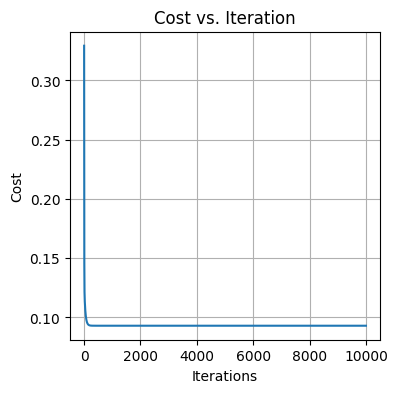

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(4,4))
ax.plot(cost_hist)
ax.set_title("Linear Regression Cost vs. Iteration")
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")
ax.grid(True)
plt.show()

In [ ]:
x_test = np.array([
    [0.4, 0.7, 0.2],
    [0.8, 0.1, 0.5],
    [0.2, 0.9, 0.3]
])
y_test = np.array([0.4, 0.7, 0.2])

In [ ]:
pred = np.dot(w_final, x_test[0]) + b_final
print(pred)

0.3288707764893256


In [ ]:
# how can we get to know that our model is predicting correctly. thats evaluation.
# we have calculated prediction for x_test[0], the first example.

error = pred - y_test[0]
sq_error = error ** 2
mse = np.mean(sq_error)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.005059366437231478


In [ ]:
predictions = np.dot(w_final , x_test) + b_final

err = predictions - y_test
sq_err = err ** 2
mse = np.mean(sq_err)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.01748527406258532


In [ ]:
def logisitc_gradient_descent(x,y,w,b,lambda_, alpha, iters):
  m,n = x.shape
  w = w.copy()
  cost_hist = []
  # b = 0

  for i in range(iters):
    dj_dw , dj_db = compute_logisitic_gradient(x,y,w,b,lambda_)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i < 10000:
      cost_hist.append(compute_regularized_logisitc_cost(x,y,w,b,lambda_))

    if i % math.ceil(iters / 10) == 0:
      print(f"Iterations: {i}, Cost: {cost_hist[-1]}")

  return w , b , cost_hist

In [ ]:
w_f, b_f, cost_hist = logisitc_gradient_descent(x_train, y_train, w,b,lambda_tmp, alpha, iters)

print(f"w: {w_f}")
print(f"b: {b_f}")
print(cost_hist[:5])

Iterations: 0, Cost: 0.9576530132700637
Iterations: 1000, Cost: 0.634444191610624
Iterations: 2000, Cost: 0.6344441915983506
Iterations: 3000, Cost: 0.6344441915983506
Iterations: 4000, Cost: 0.6344441915983507
Iterations: 5000, Cost: 0.6344441915983507
Iterations: 6000, Cost: 0.6344441915983507
Iterations: 7000, Cost: 0.6344441915983507
Iterations: 8000, Cost: 0.6344441915983507
Iterations: 9000, Cost: 0.6344441915983507
w: [ 0.24015071 -0.54447374  0.34986138]
b: -0.3000942586941772
[np.float64(0.9576530132700637), np.float64(0.9336588750391247), np.float64(0.9112712226772566), np.float64(0.8904115553546065), np.float64(0.8710009904546003)]


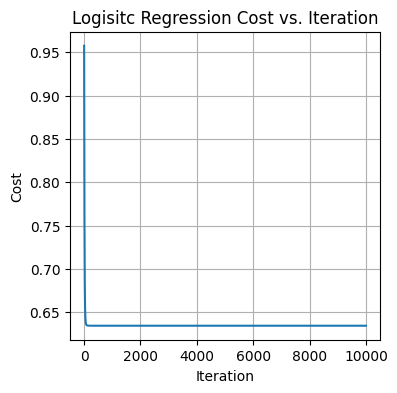

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(4,4))

ax.plot(cost_hist)
ax.set_title("Logisitc Regression Cost vs. Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost")
ax.grid(True)
plt.show()

In [ ]:
predictions = np.dot(w_f , x_test) + b_f
print(predictions)
err = predictions - y_test
sq_err = err ** 2
mse = np.mean(sq_err)

print(f"Mean Squared Error: {mse}")

[-0.56964069  0.12843911 -0.41934257]
Mean Squared Error: 0.5501567091192042
